In [2]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import hypernetx as hnx
import networkx as nx
import pandas as pd
%load_ext autoreload
%autoreload 2
import matrix_utils as mu
import Erdos_Renyi as er
import hypergraph_algebra as hga
from hypernetx.drawing.util import layout_with_radius


In [78]:
def signed_incidence_to_line_graph_and_draw(M, vertex_labels=None):
    n, m = M.shape
    if vertex_labels is None:
        vertex_labels = [str(i) for i in range(n)]

    G = nx.Graph()
    node_colors = []
    node_labels = {}
    edge_labels = {}

    for j in range(m):
        col = M[:, j]
        nz = col[col != 0]
        if len(nz) == 0:
            raise ValueError(f"Column {j} is empty.")
        if np.all(nz == 1):
            node_colors.append("green")
        elif np.all(nz == -1):
            node_colors.append("red")
        else:
            raise ValueError(f"Column {j} is not uniformly signed.")
        G.add_node(j)
        node_labels[j] = f"e{j}"

    for i in range(m):
        for j in range(i + 1, m):
            shared = np.where((M[:, i] != 0) & (M[:, j] != 0))[0]
            if len(shared) > 0:
                G.add_edge(i, j)
                edge_labels[(i, j)] = ", ".join(vertex_labels[k] for k in shared)

    pos = nx.spring_layout(G, seed=int(time.time()))

    nx.draw_networkx_edges(G, pos)
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, edgecolors="black", node_size=800)
    nx.draw_networkx_labels(G, pos, labels=node_labels)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=10)

    plt.axis("off")

def draw_each(H,I, **kwargs):
    plt.figure(figsize=(28, 10))

    #plt.subplot(131)
    node_and_edge_radius_func = lambda v: len(H.nodes[v]) if v in H.nodes else len(H.edges[v])
    pos = hnx.draw(H, 
             **kwargs, 
             node_radius=node_and_edge_radius_func,
             with_node_labels=True,with_edge_labels=False,fill_edges=True,
            layout=layout_with_radius)
    
    #plt.subplot(132)
    #signed_incidence_to_line_graph_and_draw(I)
    
    #plt.subplot(133)
    #hnx.draw_incidence_upset(
    #    H, edge_labels_on_axis=False,
    #    **kwargs
    #)

    plt.show()

def draw_signed_hypergraph(I, one_indexed_nodes=False):
    n,m = I.shape

    d = {"edges": [], "nodes": []}
    edge_signs = {f"e{j+1}": [] for j in range(m)}

    for i in range(n):
        for j in range(m):
            value = I[i][j]
            if value != 0:
                edge_name = f"e{j}"
                node_name = i + 1 if one_indexed_nodes else i

                d["edges"].append(edge_name)
                d["nodes"].append(node_name)
                edge_signs[edge_name] = value


    df = pd.DataFrame(d)
    H = hnx.Hypergraph(df, edge_col="edges", node_col="nodes")

    draw_each(
        H,I,
        nodes_kwargs={
            'facecolors': lambda n: 'white' if n=='4' else 'black',
            #'fontsize': 1000,
            'edgecolors': 'black'
        },
        edges_kwargs={
            'edgecolors': ['blue','green','cyan','yellow'], #['red' if edge_signs[e] == -1 else 'green' for e in H.edges()],
            #'edgecolors': {e: 'black' for e in H.edges()},
            'linewidths': 4
        }
    )



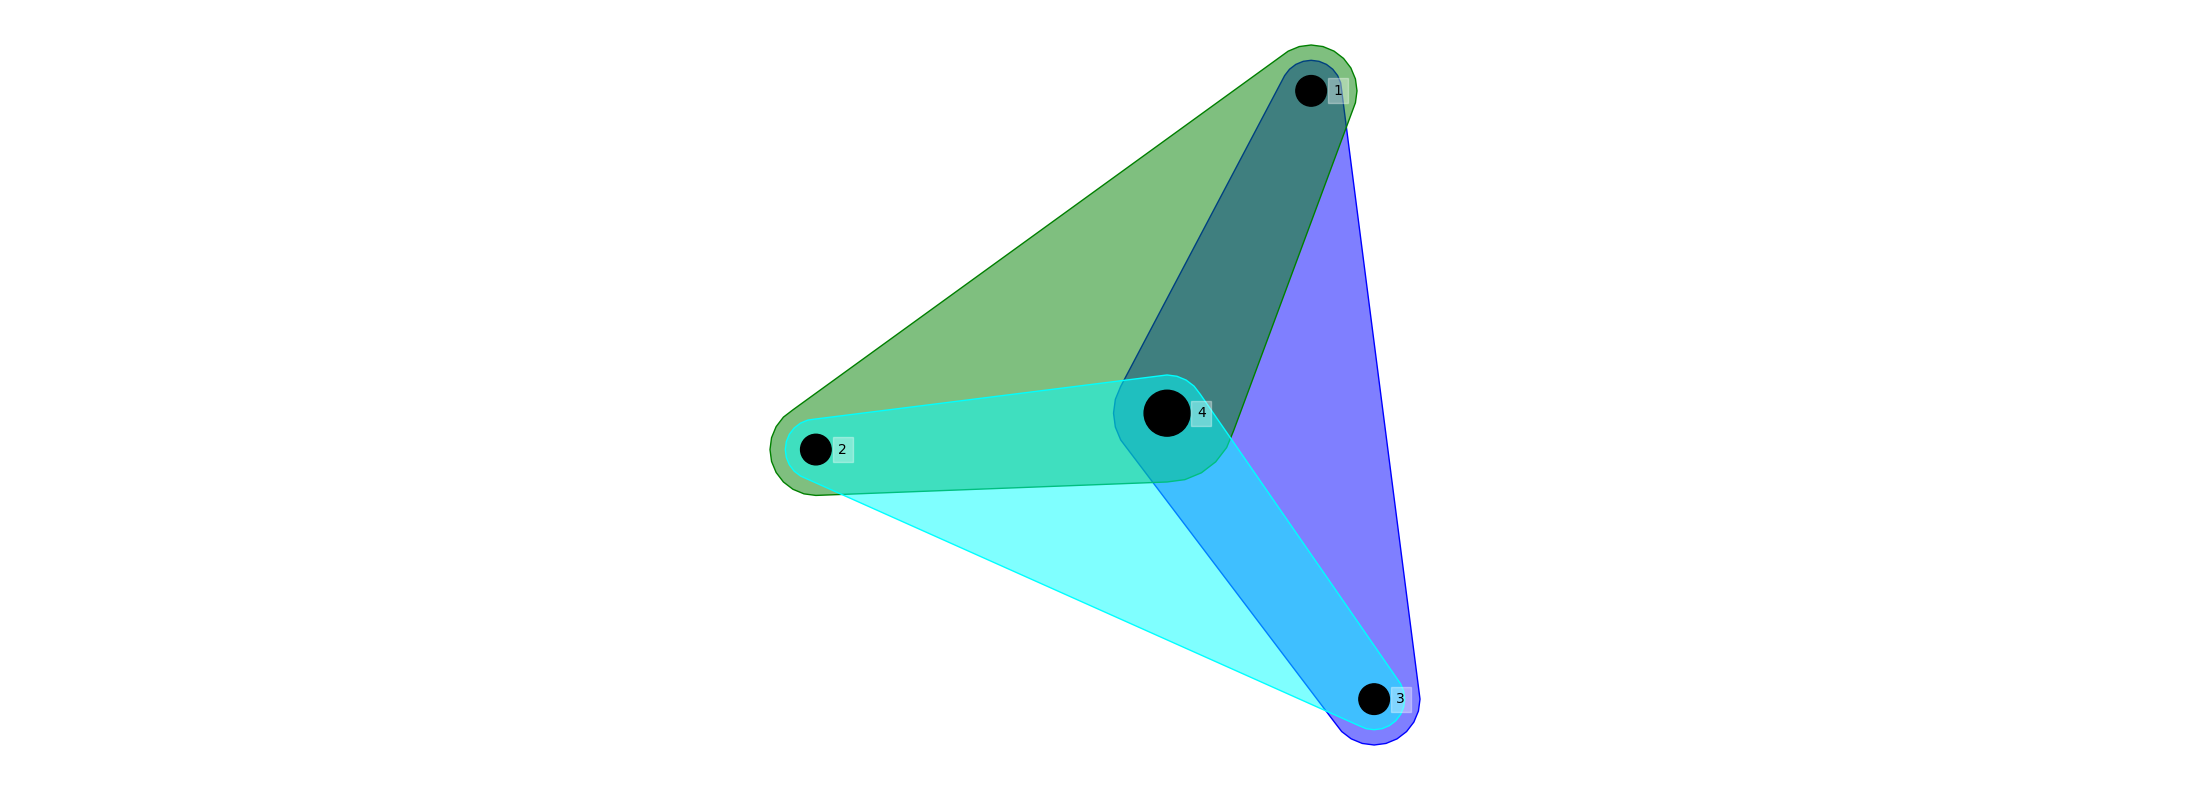

In [79]:
I = np.array([
   [0,0,1,1],
   [0,1,0,1],
   [0,1,1,0],
   [0,1,1,1]])


draw_signed_hypergraph(I,True)

In [ ]:


n = 8; pr = 0.1; restrict=True
Ts = er.generate_hypergraphs(n,pr, restrict=restrict)
Is = hga.get_incidence_tensor(Ts)
for I, T in zip(Is, Ts):
    nc = hga.negative_hyperedge_cycles(T)
    draw_signed_hypergraph(I)
    
    H, _ = hga.get_H(T, False)
    algebraic_conflict = max(np.linalg.eigvals(H))
    fi = hga.compute_fi(H)[0]
    print(f"lambda_n: {algebraic_conflict}")
    print(f"FI (H - SHS): {fi}")
    if nc != []:
        print(f"FI (DFS): {hga.hyper_frustration_index(T)}")
        print(f"Negative cycle: {nc}")
    else:
        print(f"FI (DFS): 0")